# Attention Mechanisms Illustrated

This notebook provides a hands-on walkthrough of attention mechanisms, from basic concepts to self-attention and multi-head attention.

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

## 1. Setup: A Simple Sentence

Let's work with a concrete example sentence and create simple embeddings.

In [14]:
# Our example sentence
sentence = ["The", "cat", "sat", "on", "the", "mat"]
n = len(sentence)  # sequence length
d = 8  # embedding dimension (small for visualization)

# Create random embeddings (in practice, these would be learned)
X = torch.randn(n, d)

print(f"Sentence: {sentence}")
print(f"Sequence length (n): {n}")
print(f"Embedding dimension (d): {d}")
print(f"Input shape X: {X.shape}")

Sentence: ['The', 'cat', 'sat', 'on', 'the', 'mat']
Sequence length (n): 6
Embedding dimension (d): 8
Input shape X: torch.Size([6, 8])


## 2. Dot Product Attention (Simplest Form)

The simplest attention: how similar is each word to every other word?

$$e_{ij} = x_i^T x_j$$

**Question 1:** Before running the next cell, what shape do you expect `attention_scores` to be? Why?

<br><br><br>



In [15]:
# Compute dot product between all pairs of embeddings
# X @ X.T gives us an (n x n) matrix of similarities
attention_scores = X @ X.T

print(f"Attention scores shape: {attention_scores.shape}")
print(f"\nAttention scores (raw):\n{attention_scores}")

Attention scores shape: torch.Size([6, 6])

Attention scores (raw):
tensor([[15.7307,  2.6111, -3.0232,  0.5548, -5.8108, -3.6962],
        [ 2.6111,  7.4234, -1.3059,  0.0566, -3.5380,  4.3192],
        [-3.0232, -1.3059,  8.3666,  3.6412, -3.0255, -1.0973],
        [ 0.5548,  0.0566,  3.6412,  6.3291, -1.5793, -1.7662],
        [-5.8108, -3.5380, -3.0255, -1.5793,  6.6510, -0.8536],
        [-3.6962,  4.3192, -1.0973, -1.7662, -0.8536, 12.4448]])


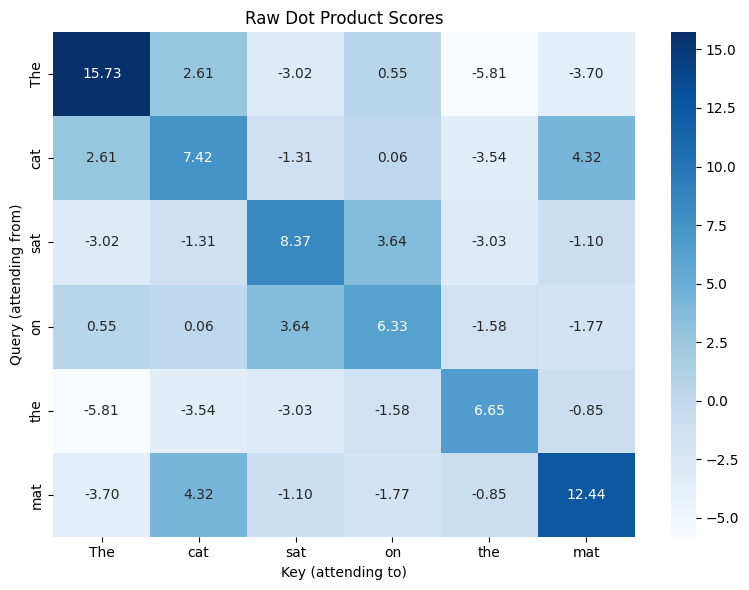

In [16]:
# Visualize the attention scores
def plot_attention(scores, tokens, title="Attention Weights"):
    plt.figure(figsize=(8, 6))
    sns.heatmap(scores.detach().numpy(), 
                xticklabels=tokens, 
                yticklabels=tokens,
                annot=True, 
                fmt='.2f',
                cmap='Blues')
    plt.xlabel('Key (attending to)')
    plt.ylabel('Query (attending from)')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_attention(attention_scores, sentence, "Raw Dot Product Scores")

**Question 2:** After softmax, what property will each row of the attention matrix have?

<br><br><br>



## 3. Softmax: Converting Scores to Weights

Apply softmax to convert scores to a probability distribution:

$$\alpha_{ij} = \frac{\exp(e_{ij})}{\sum_k \exp(e_{ik})}$$

In [17]:
# Apply softmax along the last dimension (keys)
attention_weights = F.softmax(attention_scores, dim=-1)

print(f"Attention weights (each row sums to 1):\n{attention_weights}")
print(f"\nRow sums: {attention_weights.sum(dim=-1)}")

Attention weights (each row sums to 1):
tensor([[1.0000e+00, 2.0056e-06, 7.1660e-09, 2.5656e-07, 4.4120e-10, 3.6560e-09],
        [7.7145e-03, 9.4894e-01, 1.5352e-04, 5.9964e-04, 1.6473e-05, 4.2573e-02],
        [1.1209e-05, 6.2428e-05, 9.9105e-01, 8.7875e-03, 1.1183e-05, 7.6909e-05],
        [2.8932e-03, 1.7579e-03, 6.3353e-02, 9.3137e-01, 3.4240e-04, 2.8405e-04],
        [3.8682e-06, 3.7547e-05, 6.2687e-05, 2.6621e-04, 9.9908e-01, 5.5009e-04],
        [9.7703e-08, 2.9578e-04, 1.3140e-06, 6.7315e-07, 1.6767e-06, 9.9970e-01]])

Row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


**Question 3:** Why do we divide by $\sqrt{d_k}$? What would happen without scaling when $d_k$ is large (e.g., 64 or 512)?

<br><br><br>



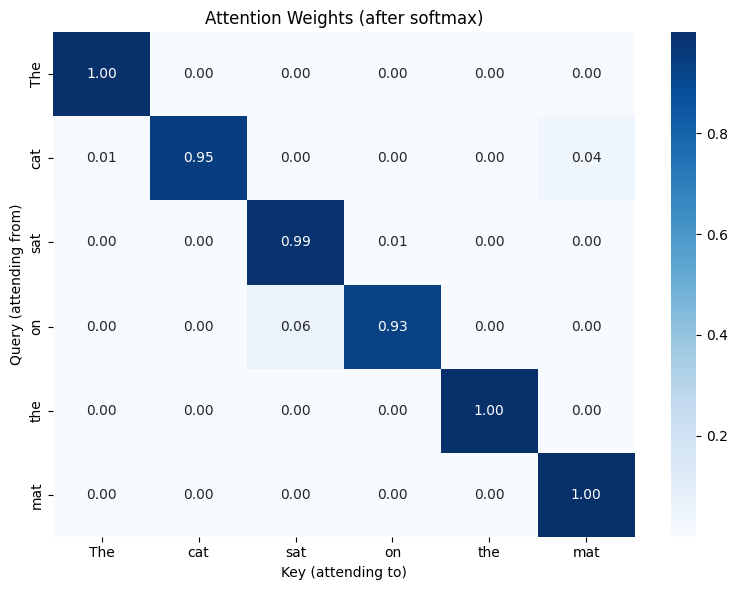

In [18]:
plot_attention(attention_weights, sentence, "Attention Weights (after softmax)")

**Question 4:** In self-attention, Q, K, V all come from the same input X. Why do we need three separate projections instead of just using X directly?

<br><br><br>



**Answer:** 
- **Q (Query)**: "What am I looking for?" - transforms input into a search query
- **K (Key)**: "What do I contain?" - transforms input into searchable descriptors  
- **V (Value)**: "What information do I provide?" - transforms input into content to retrieve

Using separate projections allows the model to learn different representations for each role. If we used X directly, the same vector would have to serve all three purposes, limiting expressivity.



## 4. Scaled Dot-Product Attention

When dimensions are large, dot products can get very large, making softmax saturate. We scale by $\sqrt{d_k}$:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Output shape: torch.Size([6, 8])


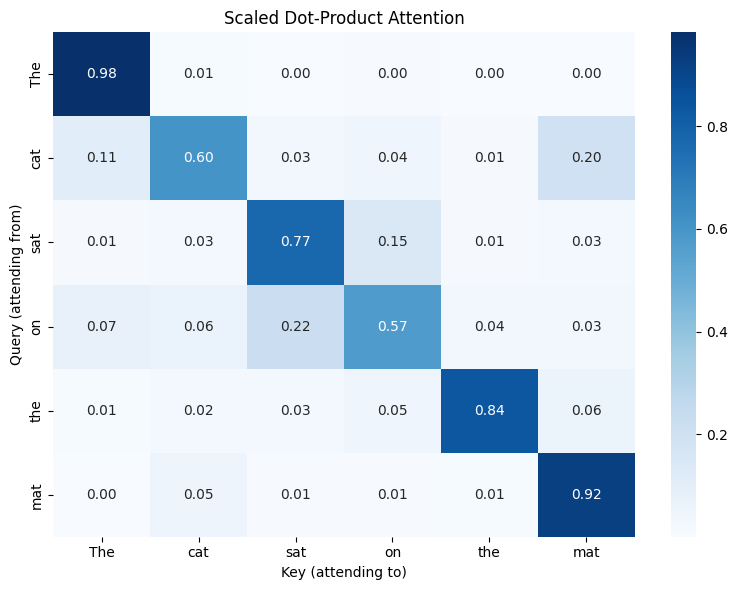

In [19]:
def scaled_dot_product_attention(Q, K, V):
    """
    Compute scaled dot-product attention.
    
    Args:
        Q: Queries (n x d_k)
        K: Keys (n x d_k)
        V: Values (n x d_v)
    
    Returns:
        output: Attention output (n x d_v)
        weights: Attention weights (n x n)
    """
    d_k = Q.shape[-1]
    
    # Step 1: Compute attention scores
    scores = Q @ K.T  # (n x n)
    
    # Step 2: Scale by sqrt(d_k)
    scores = scores / np.sqrt(d_k)
    
    # Step 3: Apply softmax
    weights = F.softmax(scores, dim=-1)
    
    # Step 4: Weighted sum of values
    output = weights @ V  # (n x d_v)
    
    return output, weights

# Using X as Q, K, and V (this is self-attention!)
output, weights = scaled_dot_product_attention(X, X, X)

print(f"Output shape: {output.shape}")
plot_attention(weights, sentence, "Scaled Dot-Product Attention")

**Question 5:** What are the shapes of $W_Q$, $W_K$, $W_V$? How does the output dimension compare to the input?

<br><br><br>



In [20]:
class SelfAttention(nn.Module):
    def __init__(self, d_model, d_k, d_v):
        super().__init__()
        self.d_k = d_k
        
        # Learned projection matrices
        self.W_Q = nn.Linear(d_model, d_k, bias=False)
        self.W_K = nn.Linear(d_model, d_k, bias=False)
        self.W_V = nn.Linear(d_model, d_v, bias=False)
    
    def forward(self, X):
        # Project to Q, K, V
        Q = self.W_Q(X)  # (n x d_k)
        K = self.W_K(X)  # (n x d_k)
        V = self.W_V(X)  # (n x d_v)
        
        # Compute attention
        scores = Q @ K.T / np.sqrt(self.d_k)
        weights = F.softmax(scores, dim=-1)
        output = weights @ V
        
        return output, weights, Q, K, V

# Create self-attention layer
d_model = d  # input dimension
d_k = 4      # key/query dimension
d_v = 4      # value dimension

self_attn = SelfAttention(d_model, d_k, d_v)
output, weights, Q, K, V = self_attn(X)

print(f"Input X shape: {X.shape}")
print(f"Q shape: {Q.shape}")
print(f"K shape: {K.shape}")
print(f"V shape: {V.shape}")
print(f"Output shape: {output.shape}")

Input X shape: torch.Size([6, 8])
Q shape: torch.Size([6, 4])
K shape: torch.Size([6, 4])
V shape: torch.Size([6, 4])
Output shape: torch.Size([6, 4])


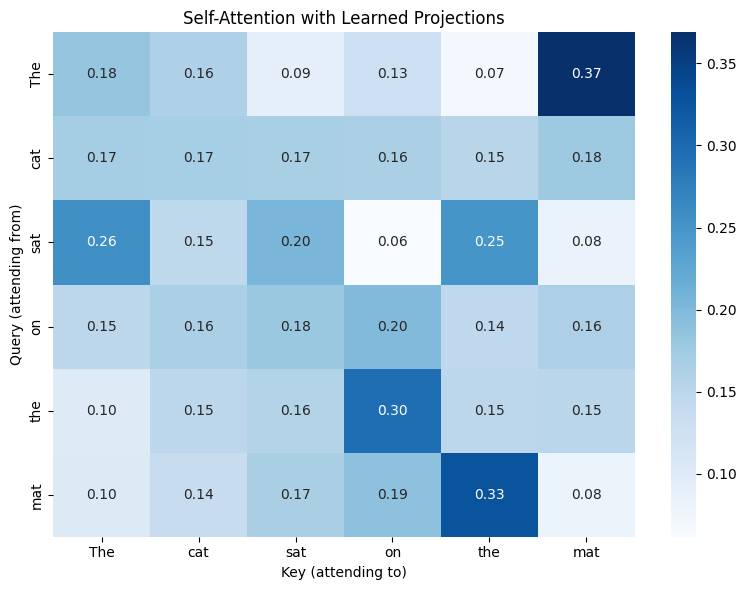

In [21]:
plot_attention(weights, sentence, "Self-Attention with Learned Projections")

## 6. Causal (Masked) Attention

For autoregressive models, we prevent attending to future positions by masking:

$$e_{ij} = \begin{cases} \frac{q_i^T k_j}{\sqrt{d_k}} & \text{if } j \leq i \\ -\infty & \text{if } j > i \end{cases}$$

**Question 6:** For autoregressive language modeling, why can't position $i$ attend to position $j > i$? What would go wrong?

<br><br><br>



**Question 7:** Look at the masked scores below. What pattern do you see? What will the attention weights look like for position 0 ("The")?

<br><br><br>



In [22]:
def causal_attention(Q, K, V):
    """
    Compute causal (masked) attention.
    Each position can only attend to itself and previous positions.
    """
    n = Q.shape[0]
    d_k = Q.shape[-1]
    
    # Compute scores
    scores = Q @ K.T / np.sqrt(d_k)
    
    # Create causal mask (upper triangular = future = masked)
    mask = torch.triu(torch.ones(n, n), diagonal=1).bool()
    
    # Apply mask: set future positions to -infinity
    scores = scores.masked_fill(mask, float('-inf'))
    
    # Softmax (masked positions become 0)
    weights = F.softmax(scores, dim=-1)
    
    # Weighted sum
    output = weights @ V
    
    return output, weights, scores

output_causal, weights_causal, scores_masked = causal_attention(Q, K, V)

print("Masked scores (future = -inf):")
print(scores_masked)

Masked scores (future = -inf):
tensor([[ 4.8245e-01,        -inf,        -inf,        -inf,        -inf,
                -inf],
        [ 4.5913e-02,  3.7960e-02,        -inf,        -inf,        -inf,
                -inf],
        [ 2.3162e-01, -3.3399e-01,  1.4544e-05,        -inf,        -inf,
                -inf],
        [-4.6689e-02,  5.2286e-02,  1.4257e-01,  2.4352e-01,        -inf,
                -inf],
        [-3.3348e-01,  5.7736e-02,  1.1660e-01,  7.4573e-01,  6.1436e-02,
                -inf],
        [-5.6602e-01, -2.9386e-01, -9.1655e-02,  4.5892e-02,  5.8864e-01,
         -8.0652e-01]], grad_fn=<MaskedFillBackward0>)


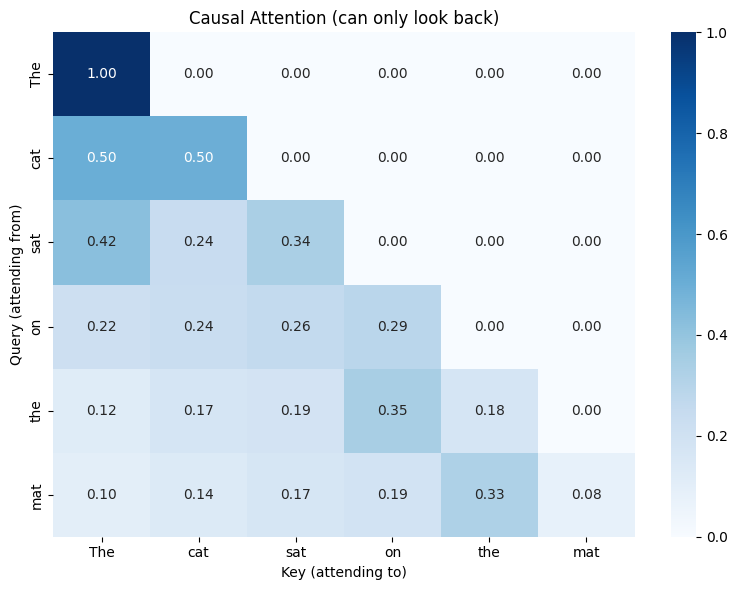

In [23]:
plot_attention(weights_causal, sentence, "Causal Attention (can only look back)")

Notice that:
- "The" (position 0) can only attend to itself
- "cat" (position 1) can attend to "The" and itself
- "mat" (position 5) can attend to all previous words

## 7. Multi-Head Attention

Run multiple attention heads in parallel, each learning different patterns:

$$\text{MultiHead}(X) = \text{Concat}(\text{head}_1, ..., \text{head}_h)W^O$$

**Question 8:** Why use multiple attention heads instead of one large attention layer? What might different heads learn?

<br><br><br>



In [26]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, d_k=None, d_v=None, causal=True):
        super().__init__()
        self.n_heads = n_heads
        self.d_k = d_k if d_k else d_model // n_heads
        self.d_v = d_v if d_v else d_model // n_heads
        self.causal = causal
        
        # Separate projections for each head
        self.W_Q = nn.Linear(d_model, n_heads * self.d_k, bias=False)
        self.W_K = nn.Linear(d_model, n_heads * self.d_k, bias=False)
        self.W_V = nn.Linear(d_model, n_heads * self.d_v, bias=False)
        self.W_O = nn.Linear(n_heads * self.d_v, d_model, bias=False)
    
    def forward(self, X):
        n = X.shape[0]
        
        # Project and reshape for multi-head
        Q = self.W_Q(X).view(n, self.n_heads, self.d_k)  # (n, h, d_k)
        K = self.W_K(X).view(n, self.n_heads, self.d_k)
        V = self.W_V(X).view(n, self.n_heads, self.d_v)
        
        # Transpose for attention: (h, n, d_k)
        Q = Q.transpose(0, 1)
        K = K.transpose(0, 1)
        V = V.transpose(0, 1)
        
        # Compute attention scores for each head
        scores = torch.bmm(Q, K.transpose(1, 2)) / np.sqrt(self.d_k)  # (h, n, n)
        
        # Apply causal mask if enabled
        if self.causal:
            mask = torch.triu(torch.ones(n, n), diagonal=1).bool()
            scores = scores.masked_fill(mask, float('-inf'))
        
        weights = F.softmax(scores, dim=-1)
        head_outputs = torch.bmm(weights, V)  # (h, n, d_v)
        
        # Concatenate heads: (n, h, d_v) -> (n, h*d_v)
        head_outputs = head_outputs.transpose(0, 1).contiguous().view(n, -1)
        
        # Final projection
        output = self.W_O(head_outputs)
        
        return output, weights

# Create multi-head attention with 2 heads (causal by default)
n_heads = 2
mha = MultiHeadAttention(d_model=d, n_heads=n_heads, causal=True)
output_mha, weights_mha = mha(X)

print(f"Input shape: {X.shape}")
print(f"Output shape: {output_mha.shape}")
print(f"Attention weights shape: {weights_mha.shape} (n_heads x n x n)")

Input shape: torch.Size([6, 8])
Output shape: torch.Size([6, 8])
Attention weights shape: torch.Size([2, 6, 6]) (n_heads x n x n)


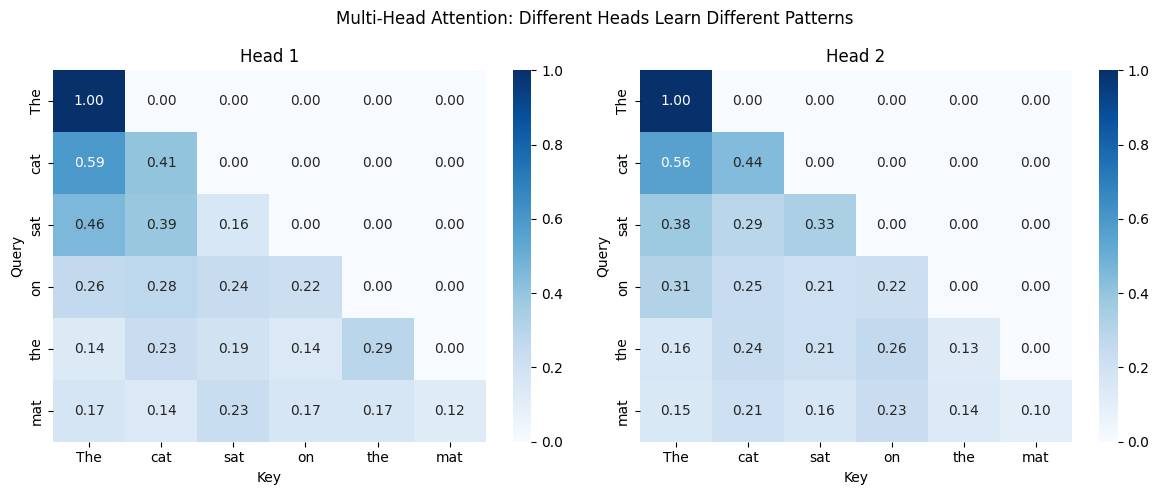

In [27]:
# Visualize attention from each head
fig, axes = plt.subplots(1, n_heads, figsize=(12, 5))

for h in range(n_heads):
    sns.heatmap(weights_mha[h].detach().numpy(),
                xticklabels=sentence,
                yticklabels=sentence,
                annot=True,
                fmt='.2f',
                cmap='Blues',
                ax=axes[h])
    axes[h].set_title(f'Head {h+1}')
    axes[h].set_xlabel('Key')
    axes[h].set_ylabel('Query')

plt.suptitle('Multi-Head Attention: Different Heads Learn Different Patterns')
plt.tight_layout()
plt.show()

**Exercise:** Before running the next cell, calculate the expected parameter count for multi-head attention.

With $d_{model} = 512$ and $h = 8$ heads:
- $W_Q$: _____ parameters
- $W_K$: _____ parameters  
- $W_V$: _____ parameters
- $W_O$: _____ parameters
- Total: _____ parameters

<br><br><br>



## 8. Parameter Count

Let's verify the parameter counts we discussed in the lecture.

In [15]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

# Typical transformer dimensions
d_model = 512
n_heads = 8
d_k = d_model // n_heads  # 64

mha_large = MultiHeadAttention(d_model=d_model, n_heads=n_heads)

print(f"Model dimension (d): {d_model}")
print(f"Number of heads (h): {n_heads}")
print(f"Key/Value dimension (d_k): {d_k}")
print(f"\nParameter count: {count_parameters(mha_large):,}")
print(f"Expected (4 * d^2): {4 * d_model**2:,}")

Model dimension (d): 512
Number of heads (h): 8
Key/Value dimension (d_k): 64

Parameter count: 1,048,576
Expected (4 * d^2): 1,048,576
